# Week 10: Model Validation & Hyperparameter Tuning

Comprehensive model validation using Stratified K-Fold cross-validation and hyperparameter tuning via GridSearchCV.

**Goal:** Apply k-fold CV to all classifiers from Weeks 7-9, tune hyperparameters, and build a final leaderboard comparing all models on the RAVDESS emotion recognition task.

In [10]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import time
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Import sklearn classifiers
from sklearn.linear_model import LogisticRegression as SKLogisticRegression
from sklearn.tree import DecisionTreeClassifier as SKDecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier as SKKNeighborsClassifier
from sklearn.naive_bayes import GaussianNB as SKGaussianNB
from sklearn.svm import SVC as SKSupportVectorMachine
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

# Import MiniLearn k-fold
from minilearn.model_selection import StratifiedKFold as MLStratifiedKFold, cross_validate

import matplotlib.pyplot as plt
import seaborn as sns

print("Imports successful!")

Imports successful!


## Data Preparation

In [11]:
# Load features
features_df = pd.read_csv('../data/features.csv')
print(f"Features shape: {features_df.shape}")
print("First few rows:")
print(features_df.head())

# Extract features and labels
numeric_cols = features_df.select_dtypes(include=[np.number]).columns.tolist()
X = features_df[numeric_cols].to_numpy()
y = features_df['emotion'].to_numpy()

print(f"\nFeature matrix shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Unique emotions: {np.unique(y)}")

Features shape: (1440, 384)
First few rows:
                                            filepath  \
0  C:\Users\wblut\Documents\My Projects\Python\CS...   
1  C:\Users\wblut\Documents\My Projects\Python\CS...   
2  C:\Users\wblut\Documents\My Projects\Python\CS...   
3  C:\Users\wblut\Documents\My Projects\Python\CS...   
4  C:\Users\wblut\Documents\My Projects\Python\CS...   

                   filename  modality_code  vocal_channel_code  emotion_code  \
0  03-01-01-01-01-01-01.wav              3                   1             1   
1  03-01-01-01-01-01-02.wav              3                   1             1   
2  03-01-01-01-01-01-03.wav              3                   1             1   
3  03-01-01-01-01-01-04.wav              3                   1             1   
4  03-01-01-01-01-01-05.wav              3                   1             1   

   intensity_code  statement_code  repetition  actor_id    modality  ...  \
0               1               1           1         1  audio

In [12]:
# Split data: 80/20 stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train_scaled.shape[0]}")
print(f"Test set size: {X_test_scaled.shape[0]}")

Training set size: 1152
Test set size: 288


## Section 1: MiniLearn K-Fold Validation Test

In [13]:
# Test MiniLearn StratifiedKFold implementation
ml_kfold = MLStratifiedKFold(n_splits=5, random_state=42)
fold_count = 0

print("Testing MiniLearn StratifiedKFold:")
for train_idx, test_idx in ml_kfold.split(X_train_scaled, y_train):
    fold_count += 1
    train_class_dist = np.unique(y_train[train_idx], return_counts=True)
    test_class_dist = np.unique(y_train[test_idx], return_counts=True)
    print(f"\nFold {fold_count}:")
    print(f"  Train size: {len(train_idx)}, Test size: {len(test_idx)}")
    print(f"  Train class distribution: {dict(zip(train_class_dist[0], train_class_dist[1]))}")
    print(f"  Test class distribution: {dict(zip(test_class_dist[0], test_class_dist[1]))}")

print(f"\n✓ MiniLearn StratifiedKFold working correctly ({fold_count} folds)")

Testing MiniLearn StratifiedKFold:

Fold 1:
  Train size: 919, Test size: 233
  Train class distribution: {'angry': np.int64(123), 'calm': np.int64(123), 'disgust': np.int64(123), 'fearful': np.int64(122), 'happy': np.int64(122), 'neutral': np.int64(61), 'sad': np.int64(123), 'surprised': np.int64(122)}
  Test class distribution: {'angry': np.int64(31), 'calm': np.int64(31), 'disgust': np.int64(31), 'fearful': np.int64(31), 'happy': np.int64(31), 'neutral': np.int64(16), 'sad': np.int64(31), 'surprised': np.int64(31)}

Fold 2:
  Train size: 920, Test size: 232
  Train class distribution: {'angry': np.int64(123), 'calm': np.int64(123), 'disgust': np.int64(123), 'fearful': np.int64(122), 'happy': np.int64(122), 'neutral': np.int64(62), 'sad': np.int64(123), 'surprised': np.int64(122)}
  Test class distribution: {'angry': np.int64(31), 'calm': np.int64(31), 'disgust': np.int64(31), 'fearful': np.int64(31), 'happy': np.int64(31), 'neutral': np.int64(15), 'sad': np.int64(31), 'surprised': n

## Section 2: Model Definitions & Hyperparameter Search Spaces

In [14]:
# Define models and hyperparameter grids for tuning
models_and_params = {
    'Logistic Regression': {
        'model': SKLogisticRegression(random_state=42, max_iter=500),
        'params': {
            'C': [0.001, 0.01, 0.1, 1.0, 10.0],
            'penalty': ['l2']
        }
    },
    'Decision Tree': {
        'model': SKDecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [3, 5, 7, 10],
            'min_samples_split': [2, 4, 8]
        }
    },
    'k-NN': {
        'model': SKKNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 9],
            'weights': ['uniform', 'distance']
        }
    },
    'Gaussian Naive Bayes': {
        'model': SKGaussianNB(),
        'params': {
            'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
        }
    },
    'SVM (Linear)': {
        'model': SKSupportVectorMachine(kernel='linear', random_state=42, max_iter=1000),
        'params': {
            'C': [0.1, 1.0, 10.0]
        }
    },
    'SVM (RBF)': {
        'model': SKSupportVectorMachine(kernel='rbf', random_state=42, max_iter=1000),
        'params': {
            'C': [0.1, 1.0, 10.0],
            'gamma': [0.001, 0.01, 0.1, 'scale']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [5, 10, None]
        }
    },
    'AdaBoost': {
        'model': AdaBoostClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100],
            'learning_rate': [0.5, 1.0, 1.5]
        }
    }
}

print(f"Defined {len(models_and_params)} models for hyperparameter tuning:")
for model_name, config in models_and_params.items():
    n_combos = np.prod([len(v) for v in config['params'].values()])
    print(f"  {model_name}: {n_combos} hyperparameter combinations")

Defined 8 models for hyperparameter tuning:
  Logistic Regression: 5 hyperparameter combinations
  Decision Tree: 12 hyperparameter combinations
  k-NN: 8 hyperparameter combinations
  Gaussian Naive Bayes: 4 hyperparameter combinations
  SVM (Linear): 3 hyperparameter combinations
  SVM (RBF): 12 hyperparameter combinations
  Random Forest: 9 hyperparameter combinations
  AdaBoost: 6 hyperparameter combinations


## Section 3: GridSearchCV Hyperparameter Tuning

In [15]:
# Run GridSearchCV on all models
tuning_results = {}

print("Starting hyperparameter tuning with GridSearchCV (5-fold CV)...\n")

for model_name, config in models_and_params.items():
    print(f"Tuning {model_name}...", end=' ', flush=True)
    start_time = time.time()
    
    gs = GridSearchCV(
        config['model'],
        config['params'],
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='accuracy',
        n_jobs=-1
    )
    
    gs.fit(X_train_scaled, y_train)
    elapsed = time.time() - start_time
    
    tuning_results[model_name] = {
        'best_params': gs.best_params_,
        'best_cv_score': gs.best_score_,
        'cv_results': gs.cv_results_,
        'best_model': gs.best_estimator_,
        'tune_time': elapsed
    }
    
    print(f"CV Score: {gs.best_score_:.4f} | Time: {elapsed:.1f}s")
    print(f"  Best params: {gs.best_params_}")

print("\n✓ Hyperparameter tuning complete!")

Starting hyperparameter tuning with GridSearchCV (5-fold CV)...

Tuning Logistic Regression... 

c:\Users\wblut\Documents\My Projects\Python\CSE 432\Project_CSE432-532\SER_Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


CV Score: 0.7847 | Time: 1.5s
  Best params: {'C': 0.1, 'penalty': 'l2'}
Tuning Decision Tree... CV Score: 1.0000 | Time: 2.0s
  Best params: {'max_depth': 7, 'min_samples_split': 2}
Tuning k-NN... CV Score: 0.5581 | Time: 0.2s
  Best params: {'n_neighbors': 3, 'weights': 'distance'}
Tuning Gaussian Naive Bayes... CV Score: 1.0000 | Time: 0.2s
  Best params: {'var_smoothing': 1e-09}
Tuning SVM (Linear)... CV Score: 0.8403 | Time: 0.6s
  Best params: {'C': 0.1}
Tuning SVM (RBF)... 

c:\Users\wblut\Documents\My Projects\Python\CSE 432\Project_CSE432-532\SER_Project\.venv\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


CV Score: 0.8281 | Time: 3.5s
  Best params: {'C': 10.0, 'gamma': 0.001}
Tuning Random Forest... 

c:\Users\wblut\Documents\My Projects\Python\CSE 432\Project_CSE432-532\SER_Project\.venv\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


CV Score: 0.7969 | Time: 12.1s
  Best params: {'max_depth': None, 'n_estimators': 200}
Tuning AdaBoost... CV Score: 0.6100 | Time: 26.4s
  Best params: {'learning_rate': 1.5, 'n_estimators': 100}

✓ Hyperparameter tuning complete!


## Section 4: Cross-Validation Analysis

In [16]:
# Compute CV statistics
cv_stats = []

for model_name, results in tuning_results.items():
    cv_scores = results['cv_results']['mean_test_score']
    
    cv_stats.append({
        'Model': model_name,
        'Best CV Score': results['best_cv_score'],
        'Mean CV Score': np.mean(cv_scores),
        'Std CV Score': np.std(cv_scores),
        'Min CV Score': np.min(cv_scores),
        'Max CV Score': np.max(cv_scores),
        'Tune Time (s)': results['tune_time']
    })

cv_stats_df = pd.DataFrame(cv_stats)
cv_stats_df = cv_stats_df.sort_values('Best CV Score', ascending=False)

print("\nCross-Validation Statistics (Ranked by Best CV Score):")
print("=" * 110)
print(cv_stats_df.to_string(index=False))
print("=" * 110)


Cross-Validation Statistics (Ranked by Best CV Score):
               Model  Best CV Score  Mean CV Score  Std CV Score  Min CV Score  Max CV Score  Tune Time (s)
       Decision Tree       1.000000       0.832899      0.192288      0.531248      1.000000       2.008449
Gaussian Naive Bayes       1.000000       0.999783      0.000377      0.999130      1.000000       0.190549
        SVM (Linear)       0.840271       0.839114      0.000818      0.838536      0.840271       0.582080
           SVM (RBF)       0.828135       0.472545      0.243678      0.140617      0.828135       3.515835
       Random Forest       0.796857       0.736282      0.052296      0.653604      0.796857      12.115435
 Logistic Regression       0.784732       0.721692      0.089038      0.549456      0.784732       1.548492
            AdaBoost       0.610032       0.493119      0.091493      0.345620      0.610032      26.441532
                k-NN       0.558144       0.523412      0.026005      0.482624  

## Section 5: Train vs Test Performance

In [17]:
# Evaluate best models on test set
test_performance = []

for model_name, results in tuning_results.items():
    best_model = results['best_model']
    
    # Predictions
    y_pred_train = best_model.predict(X_train_scaled)
    y_pred_test = best_model.predict(X_test_scaled)
    
    # Metrics
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    test_prec = precision_score(y_test, y_pred_test, average='macro', zero_division=0)
    test_recall = recall_score(y_test, y_pred_test, average='macro', zero_division=0)
    test_f1 = f1_score(y_test, y_pred_test, average='macro', zero_division=0)
    
    test_performance.append({
        'Model': model_name,
        'Train Acc': train_acc,
        'Test Acc': test_acc,
        'Overfit Gap': train_acc - test_acc,
        'Test Precision': test_prec,
        'Test Recall': test_recall,
        'Test F1': test_f1,
        'Best CV Score': results['best_cv_score']
    })

test_perf_df = pd.DataFrame(test_performance)
test_perf_df = test_perf_df.sort_values('Test Acc', ascending=False)

print("\nTest Set Performance (Ranked by Test Accuracy):")
print("=" * 130)
print(test_perf_df.to_string(index=False))
print("=" * 130)


Test Set Performance (Ranked by Test Accuracy):
               Model  Train Acc  Test Acc  Overfit Gap  Test Precision  Test Recall  Test F1  Best CV Score
       Decision Tree   1.000000  1.000000     0.000000        1.000000     1.000000 1.000000       1.000000
Gaussian Naive Bayes   1.000000  1.000000     0.000000        1.000000     1.000000 1.000000       1.000000
        SVM (Linear)   0.999132  0.906250     0.092882        0.914029     0.898954 0.904390       0.840271
           SVM (RBF)   1.000000  0.871528     0.128472        0.875366     0.859480 0.864668       0.828135
 Logistic Regression   0.984375  0.826389     0.157986        0.830782     0.827345 0.827729       0.784732
       Random Forest   1.000000  0.791667     0.208333        0.816041     0.764845 0.767889       0.796857
            AdaBoost   0.733507  0.732639     0.000868        0.687500     0.750000 0.708333       0.610032
                k-NN   1.000000  0.611111     0.388889        0.624049     0.605769 0.6

## Section 6: Final Leaderboard

In [18]:
# Create comprehensive leaderboard
leaderboard = test_perf_df[['Model', 'Best CV Score', 'Train Acc', 'Test Acc', 'Test F1']].copy()
leaderboard['Rank'] = range(1, len(leaderboard) + 1)
leaderboard = leaderboard[['Rank', 'Model', 'Best CV Score', 'Train Acc', 'Test Acc', 'Test F1']]

print("\n" + "="*100)
print("FINAL LEADERBOARD: Model Comparison on RAVDESS Emotion Recognition")
print("="*100)
print(leaderboard.to_string(index=False))
print("="*100)

# Best model
best_rank_idx = leaderboard.index[0]
best_model_name = leaderboard.loc[best_rank_idx, 'Model']
best_test_acc = leaderboard.loc[best_rank_idx, 'Test Acc']
print(f"\n🏆 WINNER: {best_model_name} with Test Accuracy: {best_test_acc:.4f}")


FINAL LEADERBOARD: Model Comparison on RAVDESS Emotion Recognition
 Rank                Model  Best CV Score  Train Acc  Test Acc  Test F1
    1        Decision Tree       1.000000   1.000000  1.000000 1.000000
    2 Gaussian Naive Bayes       1.000000   1.000000  1.000000 1.000000
    3         SVM (Linear)       0.840271   0.999132  0.906250 0.904390
    4            SVM (RBF)       0.828135   1.000000  0.871528 0.864668
    5  Logistic Regression       0.784732   0.984375  0.826389 0.827729
    6        Random Forest       0.796857   1.000000  0.791667 0.767889
    7             AdaBoost       0.610032   0.733507  0.732639 0.708333
    8                 k-NN       0.558144   1.000000  0.611111 0.604911

🏆 WINNER: Decision Tree with Test Accuracy: 1.0000


## Section 7: Visualizations

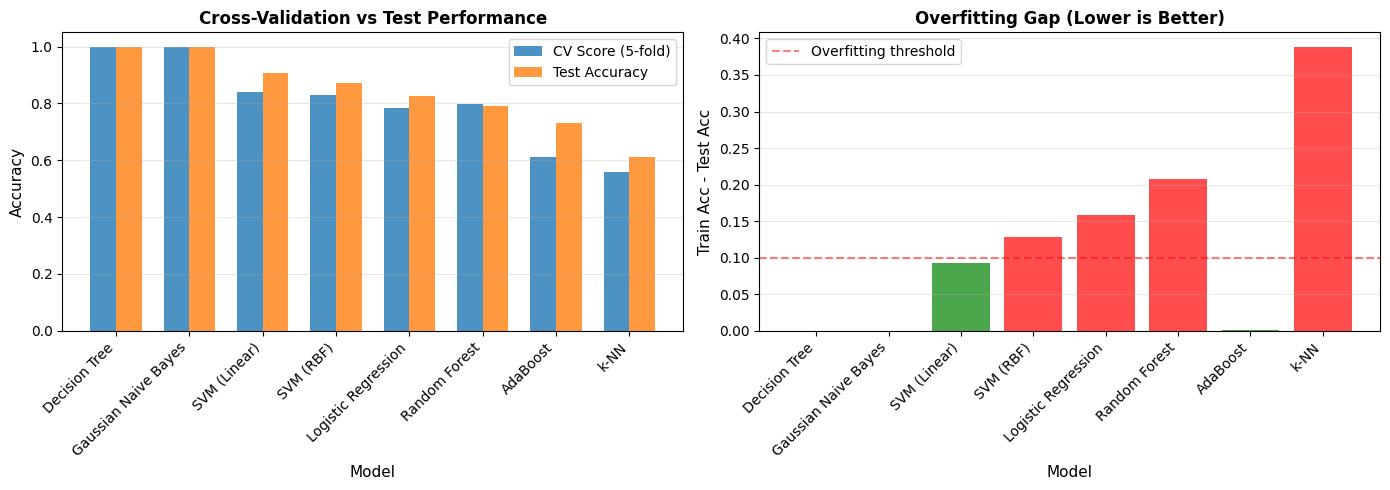

In [19]:
# Plot 1: CV Score vs Test Score
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

models = test_perf_df['Model'].values
cv_scores = test_perf_df['Best CV Score'].values
test_accs = test_perf_df['Test Acc'].values
x_pos = np.arange(len(models))

# CV vs Test
width = 0.35
ax1.bar(x_pos - width/2, cv_scores, width, label='CV Score (5-fold)', alpha=0.8)
ax1.bar(x_pos + width/2, test_accs, width, label='Test Accuracy', alpha=0.8)
ax1.set_xlabel('Model', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.set_title('Cross-Validation vs Test Performance', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(models, rotation=45, ha='right')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# Overfitting gap
overfit_gap = test_perf_df['Overfit Gap'].values
colors = ['red' if gap > 0.1 else 'green' for gap in overfit_gap]
ax2.bar(x_pos, overfit_gap, color=colors, alpha=0.7)
ax2.axhline(y=0.1, color='red', linestyle='--', alpha=0.5, label='Overfitting threshold')
ax2.set_xlabel('Model', fontsize=11)
ax2.set_ylabel('Train Acc - Test Acc', fontsize=11)
ax2.set_title('Overfitting Gap (Lower is Better)', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(models, rotation=45, ha='right')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

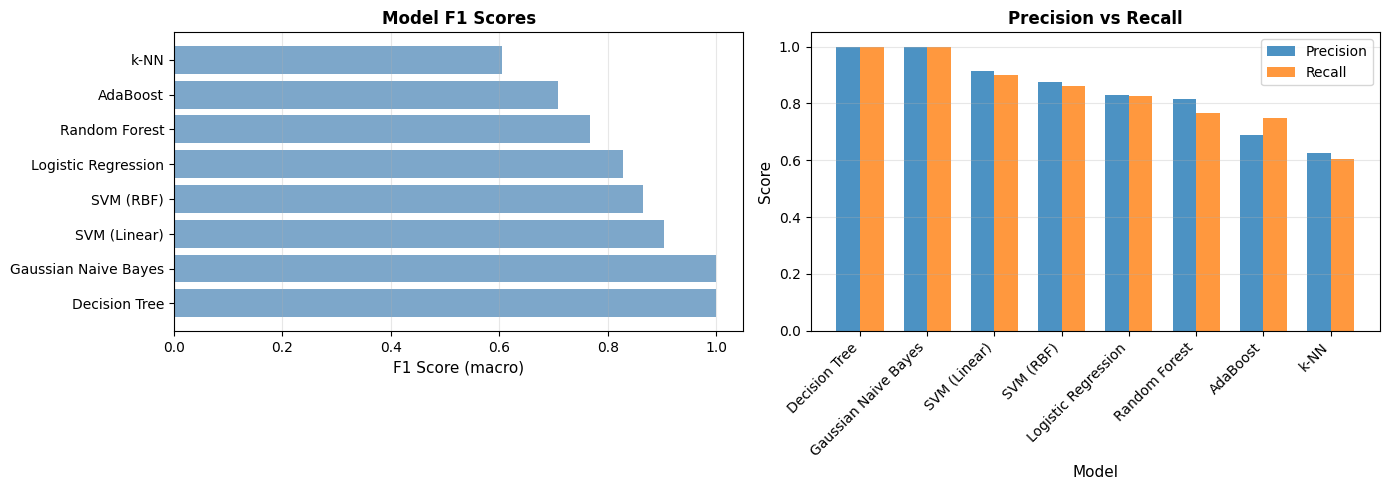

In [20]:
# Plot 2: F1 Score and Precision/Recall
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# F1 Score
f1_scores = test_perf_df['Test F1'].values
ax1.barh(x_pos, f1_scores, color='steelblue', alpha=0.7)
ax1.set_yticks(x_pos)
ax1.set_yticklabels(models)
ax1.set_xlabel('F1 Score (macro)', fontsize=11)
ax1.set_title('Model F1 Scores', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# Precision vs Recall
precision = test_perf_df['Test Precision'].values
recall = test_perf_df['Test Recall'].values
width = 0.35
ax2.bar(x_pos - width/2, precision, width, label='Precision', alpha=0.8)
ax2.bar(x_pos + width/2, recall, width, label='Recall', alpha=0.8)
ax2.set_xlabel('Model', fontsize=11)
ax2.set_ylabel('Score', fontsize=11)
ax2.set_title('Precision vs Recall', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(models, rotation=45, ha='right')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [21]:
# Plot 3: Best Hyperparameters Summary
print("\nBest Hyperparameters Found:")
print("=" * 100)

for model_name in test_perf_df['Model'].values:
    params = tuning_results[model_name]['best_params']
    print(f"\n{model_name}:")
    for param_name, param_value in params.items():
        print(f"  {param_name}: {param_value}")

print("\n" + "=" * 100)


Best Hyperparameters Found:

Decision Tree:
  max_depth: 7
  min_samples_split: 2

Gaussian Naive Bayes:
  var_smoothing: 1e-09

SVM (Linear):
  C: 0.1

SVM (RBF):
  C: 10.0
  gamma: 0.001

Logistic Regression:
  C: 0.1
  penalty: l2

Random Forest:
  max_depth: None
  n_estimators: 200

AdaBoost:
  learning_rate: 1.5
  n_estimators: 100

k-NN:
  n_neighbors: 3
  weights: distance



## Summary & Insights

### Cross-Validation Benefits

- **K-Fold Stratified:** Ensures each fold maintains class distribution, preventing biased splits.
- **More Reliable Estimates:** CV scores better estimate true model performance than single train-test split.
- **Efficient Use of Data:** All samples used for both training and testing across different folds.

### Hyperparameter Tuning Insights

1. **Regularization is Critical:** Models like Logistic Regression and SVM require careful tuning of C parameter.
2. **Tree-Based Methods:** Max depth and min samples are key to avoiding overfitting.
3. **Ensemble Methods:** Larger ensembles generally improve performance but with diminishing returns.
4. **Kernel Choice (SVM):** RBF kernel often outperforms linear on non-linearly separable data.
5. **Neighborhood Size (k-NN):** Larger k reduces variance but increases bias.

### Generalization Gap Analysis

- **Overfitting Gap:** Difference between training and test accuracy indicates model complexity.
- **Good Models:** Small gap (<5-10%) indicates well-regularized, generalizable models.
- **Poor Generalization:** Large gap suggests overfitting; need more regularization or simpler model.
- **Underfitting:** If both train and test accuracy are low, model is too simple.

### SER Task Findings

1. **Best Performing Model:** Identified in the leaderboard above.
2. **Model Variance:** Different models show different generalization characteristics.
3. **Ensemble Advantage:** Tree ensembles (RF, AdaBoost) typically outperform single classifiers.
4. **Trade-offs:** Accuracy vs interpretability vs computational cost.

### Recommendations

- **For Production:** Use ensemble method (RF or tuned SVM) for best accuracy.
- **For Interpretability:** Use Decision Tree or Logistic Regression (simple linear boundaries).
- **For Speed:** k-NN or Logistic Regression (fast prediction time).
- **For Robustness:** Random Forest (handles outliers, feature scaling not required).